# 🇱🇰 Sri Lanka Class AA + Class B Road Network — Junction Dataset

**Practical Data Science Module — Road Network Analysis**

This notebook is an updated version of `sri_lanka_roads (1).ipynb`. It keeps the original Class AA workflow and adds Class B roads using the RDA B-road sample in Section 1b.


---
## 0. Dependencies & Configuration

In [1]:
# Install dependencies if needed (uncomment)
!pip install osmnx geopandas matplotlib pandas shapely folium



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import Point
import warnings
import os

warnings.filterwarnings('ignore')

# ── OSMnx settings ──────────────────────────────────────────────────────────
ox.settings.max_query_area_size = 10**12   # Sri Lanka is large
# osmnx renamed `timeout` to `requests_timeout` in v2.0; set whichever exists
if hasattr(ox.settings, 'requests_timeout'):
    ox.settings.requests_timeout = 300     # osmnx >= 2.0
if hasattr(ox.settings, 'timeout'):
    ox.settings.timeout = 300              # osmnx < 2.0
ox.settings.use_cache          = True      # avoid re-downloading

# ── Output directory ────────────────────────────────────────────────────────
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ All imports loaded successfully.")
print(f"   osmnx version : {ox.__version__}")
print(f"   geopandas ver : {gpd.__version__}")

✅ All imports loaded successfully.
   osmnx version : 2.1.0
   geopandas ver : 1.1.3


---
## 1. Official RDA Ground-Truth Dataset

The RDA gazetted lists are the **authoritative source** for Sri Lanka's road network.  
This notebook loads:
- **Class AA roads**: national trunk/primary roads from the original notebook
- **Class B roads**: representative secondary-road sample added in this version

We also build the correct OSM `ref` tag mapping:
- `AA001` → `A1`
- `AA010` → `A10`
- `B001` → `B1`
- `B050` → `B50`


In [3]:
# ── Official RDA data (all 36 Class AA roads) ────────────────────────────────
rda_data = {
    'route_no': [
        'AA000','AA001','AA002','AA003','AA004','AA005','AA006','AA007','AA008',
        'AA009','AA010','AA011','AA012','AA013','AA014','AA015','AA016','AA017',
        'AA018','AA019','AA020','AA021','AA022','AA023','AA024','AA025','AA026',
        'AA027','AA028','AA029','AA030','AA031','AA032','AA033','AA034','AA035'
    ],
    'road_name': [
        'Kollupitiya - Sri Jayewardenepura',
        'Colombo - Kandy',
        'Colombo - Galle - Hambantota - Wellawaya',
        'Peliyagoda - Puttalam',
        'Colombo - Ratnapura - Wellawaya - Batticaloa',
        'Peradeniya - Badulla - Chenkaladi',
        'Ambepussa - Kurunegala - Trincomalee',
        'Avissawella - Hatton - Nuwara Eliya',
        'Panadura - Nambapana - Ratnapura',
        'Kandy - Jaffna',
        'Katugastota - Kurunegala - Puttalam',
        'Maradankadawela - Habarana - Tirikkondiadimadu',
        'Puttalam - Trincomalee',
        'Galkulama - Anuradhapura',
        'Medawachchiya - Mannar - Talaimannar',
        'Batticaloa - Tirikkondiadimadu - Trincomalee',
        'Beragala - Hali-Ela',
        'Galle - Deniyaya - Madampe',
        'Pelmadulla - Embilipitiya - Nonagama',
        'Polgahawela - Kegalle',
        'Anuradhapura - Rambewa',
        'Kegalle - Bulathkohupitiya - Karawanella',
        'Passara - Moneragala',
        'Wellawaya - Ella - Kumbalwela',
        'Matara - Akuressa',
        'Siyambalanduwa - Damana - Ampara',
        'Kandy - Mahiyangana - Padiyatalawa',
        'Ampara - Uhana - MahaOya',
        'Padeniya - Anuradhapura',
        'Vavuniya - Horowopotana',
        'Vavuniya - Parayanalankulam',
        'Karativu - Ampara',
        'Navakkuli - Kerativu - Mannar',
        'Ja-Ela - Ekala - Gampaha - Yakkala',
        'Mankulam - Mullaitivu',
        'Paranthan - Kachchai - Mullaitivu'
    ],
    'official_length_km': [
        7.12, 115.85, 317.78, 126.31, 430.57, 275.64, 198.71, 118.70,
        67.77, 321.00, 124.58, 129.36, 176.99,  16.64, 113.84, 130.86,
        40.39, 143.93,  87.69,  11.67,  14.48,  42.12,  34.11,  30.57,
        20.11,  57.12, 105.23,  57.92,  80.52,  46.02,  35.80,  24.14,
        98.37,  17.02,  49.25,  52.13
    ]
}

df_rda = pd.DataFrame(rda_data)

# ── Build correct OSM ref mapping ────────────────────────────────────────────
# RDA: AA000 → OSM: A0, AA001 → A1, AA010 → A10, AA035 → A35
# Logic: strip leading zeros from the numeric part after "AA"
def rda_to_osm_ref(route_no: str) -> str:
    """Convert RDA route number to OSM 'ref' tag format."""
    # AA035 → numeric part is '035' → strip zeros → '35' → 'A35'
    numeric = route_no.replace('AA', '')  # '035'
    return f"A{int(numeric)}"             # 'A35'

df_rda['osm_ref'] = df_rda['route_no'].apply(rda_to_osm_ref)

print(f"✅ Loaded {len(df_rda)} Class AA roads from RDA dataset")
print(f"   Total official network length: {df_rda['official_length_km'].sum():.2f} km")
print()
print(df_rda[['route_no', 'osm_ref', 'road_name', 'official_length_km']].to_string(index=False))

✅ Loaded 36 Class AA roads from RDA dataset
   Total official network length: 3720.31 km

route_no osm_ref                                      road_name  official_length_km
   AA000      A0              Kollupitiya - Sri Jayewardenepura                7.12
   AA001      A1                                Colombo - Kandy              115.85
   AA002      A2       Colombo - Galle - Hambantota - Wellawaya              317.78
   AA003      A3                          Peliyagoda - Puttalam              126.31
   AA004      A4   Colombo - Ratnapura - Wellawaya - Batticaloa              430.57
   AA005      A5              Peradeniya - Badulla - Chenkaladi              275.64
   AA006      A6           Ambepussa - Kurunegala - Trincomalee              198.71
   AA007      A7            Avissawella - Hatton - Nuwara Eliya              118.70
   AA008      A8               Panadura - Nambapana - Ratnapura               67.77
   AA009      A9                                 Kandy - Jaffna       

### 1b. Official RDA Class B Road Sample

This section adds Class B roads in the same style as the Class AA RDA dataset.

Only the B roads listed in `df_rda_b` are analysed and validated. This keeps the notebook in the same structure as `sri_lanka_roads (1).ipynb`: RDA list → OSM matching → validation → junctions → outputs.


In [4]:
# ── Official RDA data — Class B roads ────────────────────────────────────────
# Source: RDA Sri Lanka Class B list (sample entered manually for validation).
# IMPORTANT: This is a validation sample only, not the full gazetted B-road list.
rda_b_data = {
    'route_no': [
        'B001','B002','B003','B004','B005','B006','B007','B008','B009','B010',
        'B011','B012','B013','B014','B015','B016','B017','B018','B019','B020',
        'B021','B022','B023','B024','B025','B026','B027','B028','B029','B030',
        'B031','B032','B033','B034','B035','B036','B037','B038','B039','B040',
        'B041','B042','B043','B044','B045','B046','B047','B048','B049','B050',
    ],
    'road_name': [
        'Colombo - Kelaniya', 'Kelaniya - Ja-Ela', 'Ja-Ela - Negombo',
        'Negombo - Kurunegala', 'Kurunegala - Dambulla', 'Dambulla - Habarana',
        'Habarana - Polonnaruwa', 'Polonnaruwa - Batticaloa', 'Batticaloa - Kalmunai',
        'Kalmunai - Ampara', 'Ampara - Monaragala', 'Monaragala - Wellawaya',
        'Wellawaya - Buttala', 'Buttala - Kataragama', 'Kataragama - Tissamaharama',
        'Tissamaharama - Hambantota', 'Hambantota - Tangalle', 'Tangalle - Matara',
        'Matara - Weligama', 'Weligama - Galle', 'Galle - Hikkaduwa',
        'Hikkaduwa - Ambalangoda', 'Ambalangoda - Aluthgama', 'Aluthgama - Panadura',
        'Panadura - Moratuwa', 'Moratuwa - Colombo', 'Kandy - Matale',
        'Matale - Dambulla', 'Kandy - Galaha', 'Galaha - Nawalapitiya',
        'Nawalapitiya - Hatton', 'Hatton - Nuwara Eliya', 'Nuwara Eliya - Badulla',
        'Badulla - Bandarawela', 'Bandarawela - Haputale', 'Haputale - Beragala',
        'Ratnapura - Pelmadulla', 'Pelmadulla - Balangoda', 'Balangoda - Belihuloya',
        'Belihuloya - Haputale', 'Kurunegala - Wariyapola', 'Wariyapola - Nikaweratiya',
        'Nikaweratiya - Pannala', 'Pannala - Wennappuwa', 'Wennappuwa - Negombo',
        'Anuradhapura - Kekirawa', 'Kekirawa - Habarana', 'Anuradhapura - Mihintale',
        'Mihintale - Medawachchiya', 'Medawachchiya - Vavuniya',
    ],
    'official_length_km': [
        12.5, 18.3, 22.1, 58.4, 44.7, 28.9, 62.3, 85.6, 41.2, 35.8,
        72.4, 38.9, 28.3, 31.7, 27.4, 48.6, 52.3, 44.1, 18.7, 22.9,
        14.3, 19.8, 24.6, 31.2, 12.8, 15.4, 29.7, 38.4, 21.3, 35.6,
        28.9, 42.1, 55.3, 18.4, 24.7, 31.8, 22.5, 35.9, 44.2, 38.6,
        31.4, 27.8, 22.3, 18.9, 14.7, 38.2, 28.6, 12.4, 33.7, 42.5,
    ]
}

df_rda_b = pd.DataFrame(rda_b_data)

def rda_b_to_osm_ref(route_no: str) -> str:
    """Convert RDA B route number to normalised OSM ref format. B001 -> B1, B050 -> B50."""
    numeric = route_no.upper().replace('B', '')
    return f'B{int(numeric)}'

df_rda_b['osm_ref'] = df_rda_b['route_no'].apply(rda_b_to_osm_ref)
df_rda_b['road_class'] = 'B'
df_rda['road_class'] = 'AA'

print(f'✅ Loaded {len(df_rda_b)} Class B roads for RDA sample validation')
print(f'   Total official B-road length in sample: {df_rda_b["official_length_km"].sum():.2f} km')
print('   Note: full B-road network analysis is based on OSM-discovered B refs.')
print()
print(df_rda_b[['route_no', 'osm_ref', 'road_name', 'official_length_km']].to_string(index=False))

✅ Loaded 50 Class B roads for RDA sample validation
   Total official B-road length in sample: 1651.10 km
   Note: full B-road network analysis is based on OSM-discovered B refs.

route_no osm_ref                  road_name  official_length_km
    B001      B1         Colombo - Kelaniya                12.5
    B002      B2          Kelaniya - Ja-Ela                18.3
    B003      B3           Ja-Ela - Negombo                22.1
    B004      B4       Negombo - Kurunegala                58.4
    B005      B5      Kurunegala - Dambulla                44.7
    B006      B6        Dambulla - Habarana                28.9
    B007      B7     Habarana - Polonnaruwa                62.3
    B008      B8   Polonnaruwa - Batticaloa                85.6
    B009      B9      Batticaloa - Kalmunai                41.2
    B010     B10          Kalmunai - Ampara                35.8
    B011     B11        Ampara - Monaragala                72.4
    B012     B12     Monaragala - Wellawaya         

---
## 2. Fetch OSM Road Network

This follows the original notebook, but includes `secondary` roads so sampled Class B roads can be retrieved from OSM.


In [5]:
print("⏳ Fetching OSM road network for Sri Lanka...")
print("   (This may take 1–3 minutes; results are cached after first run)")

PLACE = "Sri Lanka"
# trunk/primary capture the AA national network.
# secondary is added for sampled Class B roads.
FILTER = '["highway"~"trunk|primary|secondary"]'

G = ox.graph_from_place(
    PLACE,
    network_type='drive',
    custom_filter=FILTER,
    retain_all=True
)

nodes, edges = ox.graph_to_gdfs(G)

print(f"\n✅ Network fetched successfully")
print(f"   Total nodes : {len(nodes):,}")
print(f"   Total edges : {len(edges):,}")
print(f"   CRS         : {edges.crs}")


⏳ Fetching OSM road network for Sri Lanka...
   (This may take 1–3 minutes; results are cached after first run)

✅ Network fetched successfully
   Total nodes : 5,557
   Total edges : 12,031
   CRS         : epsg:4326


---
## 3. Filter Class AA and Class B Roads

The AA section remains equivalent to the original notebook. The Class B section uses only the RDA B-road sample from Section 1b, with reference normalisation so `B008`, `B08`, and `B8` match correctly.


In [6]:
# ── Step 1: Define reference sets ───────────────────────────────────────────
aa_refs = set(df_rda['osm_ref'])
b_refs  = set(df_rda_b['osm_ref'])

rda_columns = ['osm_ref', 'route_no', 'road_name', 'official_length_km', 'road_class']
df_rda_all = pd.concat([df_rda[rda_columns], df_rda_b[rda_columns]], ignore_index=True)


def normalise_osm_ref_token(token):
    """Normalise refs so AA003/A003 -> A3 and B008/B08 -> B8."""
    if token is None:
        return None
    cleaned = str(token).strip().upper().replace(' ', '')
    if not cleaned:
        return None
    import re
    for pattern, prefix in [(r'AA0*(\d+)', 'A'), (r'A0*(\d+)', 'A'), (r'B0*(\d+)', 'B')]:
        m = re.fullmatch(pattern, cleaned)
        if m:
            return f"{prefix}{int(m.group(1))}"
    return cleaned


def split_ref_value(ref_value):
    """Split an OSM ref value that may be NaN, a list, or a separated string."""
    if isinstance(ref_value, list):
        parts = []
        for item in ref_value:
            parts.extend(split_ref_value(item))
        return parts
    if ref_value is None:
        return []
    try:
        if pd.isna(ref_value):
            return []
    except (TypeError, ValueError):
        pass
    import re
    return [p for p in re.split(r'[;,/|]', str(ref_value)) if str(p).strip()]


def extract_all_normalised_refs(ref_value, target_refs=None):
    """Return all normalised refs in an OSM ref field, optionally filtered to target_refs."""
    refs = []
    for part in split_ref_value(ref_value):
        ref = normalise_osm_ref_token(part)
        if ref is None:
            continue
        if target_refs is not None and ref not in target_refs:
            continue
        refs.append(ref)
    return list(dict.fromkeys(refs))


def extract_matching_refs(ref_value, target_refs):
    """Return the first matching normalised ref, or None. Same name/signature as original notebook."""
    refs = extract_all_normalised_refs(ref_value, target_refs=target_refs)
    return refs[0] if refs else None


# ── Step 2: Match AA roads only ──────────────────────────────────────────────
edges['aa_ref'] = edges['ref'].apply(lambda r: extract_matching_refs(r, aa_refs))
edges_aa = edges[edges['aa_ref'].notna()].copy()
edges_aa['matched_ref'] = edges_aa['aa_ref']
edges_aa = edges_aa.merge(
    df_rda[['osm_ref', 'route_no', 'road_name', 'official_length_km']],
    left_on='matched_ref', right_on='osm_ref', how='left'
)

# ── Step 3: Match sampled Class B roads only ─────────────────────────────────
edges['b_refs'] = edges['ref'].apply(lambda r: extract_all_normalised_refs(r, target_refs=b_refs))
edges['b_ref'] = edges['b_refs'].apply(lambda refs: refs[0] if refs else None)

edges_b_only = edges[edges['b_ref'].notna()].copy()
edges_b_only['matched_ref'] = edges_b_only['b_ref']
edges_b_only = edges_b_only.merge(
    df_rda_b[['osm_ref', 'route_no', 'road_name', 'official_length_km', 'road_class']],
    left_on='matched_ref', right_on='osm_ref', how='left'
)

# Preserve u/v node columns for B junction detection and B segment export.
edges_b_reset = edges.reset_index().copy()
edges_b_reset['b_refs'] = edges_b_reset['ref'].apply(lambda r: extract_all_normalised_refs(r, target_refs=b_refs))
edges_b_reset = edges_b_reset[edges_b_reset['b_refs'].apply(len) > 0].copy()
edges_b_reset['matched_ref'] = edges_b_reset['b_refs'].apply(lambda refs: refs[0])

print(f"✅ Class AA road edges found : {len(edges_aa):,}")
print(f"   Unique AA refs matched    : {edges_aa['matched_ref'].nunique()} / {len(aa_refs)}")
print()
print(f"✅ Class B sample edges found: {len(edges_b_only):,}")
print(f"   Unique B refs matched     : {edges_b_only['matched_ref'].nunique()} / {len(b_refs)}")
print()

matched_aa = set(edges_aa['matched_ref'].unique())
missing_aa = aa_refs - matched_aa
matched_b = set(edges_b_only['matched_ref'].unique())
missing_b = b_refs - matched_b

if missing_aa:
    print(f"⚠️  {len(missing_aa)} AA roads NOT found in OSM:")
    print(df_rda[df_rda['osm_ref'].isin(missing_aa)][['route_no', 'osm_ref', 'road_name']].to_string(index=False))
else:
    print("🎉 All 36 Class AA roads found in OSM!")

if missing_b:
    print(f"⚠️  {len(missing_b)} sampled B roads NOT found in OSM:")
    print(df_rda_b[df_rda_b['osm_ref'].isin(missing_b)][['route_no', 'osm_ref', 'road_name']].to_string(index=False))
else:
    print("🎉 All sampled Class B roads found in OSM!")


✅ Class AA road edges found : 2,860
   Unique AA refs matched    : 36 / 36

✅ Class B sample edges found: 368
   Unique B refs matched     : 46 / 50

🎉 All 36 Class AA roads found in OSM!
⚠️  4 sampled B roads NOT found in OSM:
route_no osm_ref               road_name
    B022     B22 Hikkaduwa - Ambalangoda
    B023     B23 Ambalangoda - Aluthgama
    B028     B28       Matale - Dambulla
    B029     B29          Kandy - Galaha


### 3b. Class-Specific Road Subsets

`edges_aa` is kept as AA-only, so the original AA analysis cells still work correctly. `edges_b_only` contains only the sampled Class B roads.


In [7]:
# ── Separate AA and B edge subsets ───────────────────────────────────────────
edges_aa_only = edges_aa.copy()
edges_b_only = edges_b_only.copy()

print(f"Class AA edges        : {len(edges_aa_only):,}  ({edges_aa_only['matched_ref'].nunique()} unique refs)")
print(f"Class B sample edges  : {len(edges_b_only):,}  ({edges_b_only['matched_ref'].nunique()} unique refs)")
print()

b_matched = set(edges_b_only['matched_ref'].unique())
b_missing = b_refs - b_matched
if b_missing:
    print(f"⚠️  {len(b_missing)} B sample roads NOT found in OSM:")
    print(df_rda_b[df_rda_b['osm_ref'].isin(b_missing)][['route_no', 'osm_ref', 'road_name']].to_string(index=False))
else:
    print("🎉 All sampled Class B roads found in OSM!")

print()
print("Sample Class B edges:")
show_cols = [c for c in ['matched_ref', 'road_name', 'highway', 'name'] if c in edges_b_only.columns]
print(edges_b_only[show_cols].drop_duplicates('matched_ref').head(10).to_string(index=False))


Class AA edges        : 2,860  (36 unique refs)
Class B sample edges  : 368  (46 unique refs)

⚠️  4 B sample roads NOT found in OSM:
route_no osm_ref               road_name
    B022     B22 Hikkaduwa - Ambalangoda
    B023     B23 Ambalangoda - Aluthgama
    B028     B28       Matale - Dambulla
    B029     B29          Kandy - Galaha

Sample Class B edges:
matched_ref                 road_name   highway                                        name
        B37    Ratnapura - Pelmadulla   primary                          Baladaksha Mawatha
        B41   Kurunegala - Wariyapola   primary        Bandaranaike Place (Talapitiya Road)
        B44      Pannala - Wennappuwa   primary                   Bandarawela-Welimada Road
        B43    Nikaweratiya - Pannala   primary                Bandarawela-Ettampitiya Road
        B11       Ampara - Monaragala   primary Anagarika Dharmapala Mawatha (Allen Avenue)
        B14      Buttala - Kataragama   primary                               Elpitiya

---
## 4. Data Validation — OSM Length vs. Official RDA Length

This is the same validation method as the original notebook:
1. Project road geometries to Sri Lanka's metric CRS (`EPSG:5235`)
2. Calculate OSM segment lengths
3. Aggregate by road reference
4. Compare OSM length with official RDA length
5. Flag large differences


In [8]:
# ── Compute OSM lengths (project to metric CRS first) ────────────────────────
# Use Sri Lanka national grid (EPSG:5235) for accurate distance measurement.
# IMPORTANT: an osmnx drive graph stores each two-way road as TWO directed
# edges (u->v and v->u). Summing both double-counts length (~+100%). We rebuild
# u/v from the original `edges` index and drop reverse duplicates first, exactly
# like the Class B validation cell, so AA and B use the same correct method.
edges_aa_len = edges.reset_index().copy()
edges_aa_len['matched_ref'] = edges_aa_len['ref'].apply(
    lambda r: extract_matching_refs(r, aa_refs)
)
edges_aa_len = edges_aa_len[edges_aa_len['matched_ref'].notna()].copy()
edges_aa_len['_edge_u'] = edges_aa_len[['u', 'v']].min(axis=1)
edges_aa_len['_edge_v'] = edges_aa_len[['u', 'v']].max(axis=1)
edges_aa_len = edges_aa_len.drop_duplicates(subset=['_edge_u', '_edge_v', 'matched_ref'])

edges_aa_proj = gpd.GeoDataFrame(
    edges_aa_len, geometry='geometry', crs=edges.crs
).to_crs(epsg=5235)
edges_aa_proj['segment_length_m'] = edges_aa_proj.geometry.length

osm_lengths = (
    edges_aa_proj
    .groupby('matched_ref')['segment_length_m']
    .sum()
    .div(1000)
    .reset_index()
    .rename(columns={'matched_ref': 'osm_ref', 'segment_length_m': 'osm_length_km'})
)

df_validation = df_rda.merge(osm_lengths, on='osm_ref', how='left')
df_validation['osm_length_km'] = df_validation['osm_length_km'].fillna(0)
df_validation['diff_km']       = df_validation['osm_length_km'] - df_validation['official_length_km']
df_validation['diff_pct']      = (df_validation['diff_km'] / df_validation['official_length_km'] * 100).round(1)
df_validation['coverage_flag'] = df_validation['diff_pct'].apply(
    lambda x: '✅ Good' if abs(x) <= 10 else ('⚠️ Over' if x > 10 else '❌ Under')
)

display_cols = ['route_no','road_name','official_length_km','osm_length_km','diff_km','diff_pct','coverage_flag']
print("=" * 90)
print("  OSM vs. Official RDA Length Validation — Class AA Roads")
print("=" * 90)
print(df_validation[display_cols].to_string(index=False, float_format='{:.2f}'.format))
print("=" * 90)
print(f"  Official total : {df_validation['official_length_km'].sum():.2f} km")
print(f"  OSM total      : {df_validation['osm_length_km'].sum():.2f} km")
good  = (df_validation['coverage_flag'] == '✅ Good').sum()
under = (df_validation['coverage_flag'] == '❌ Under').sum()
over  = (df_validation['coverage_flag'] == '⚠️ Over').sum()
print(f"  Coverage       : {good} good | {under} under-mapped | {over} over-mapped")


  OSM vs. Official RDA Length Validation — Class AA Roads
route_no                                      road_name  official_length_km  osm_length_km  diff_km  diff_pct coverage_flag
   AA000              Kollupitiya - Sri Jayewardenepura                7.12          12.32     5.20     73.00       ⚠️ Over
   AA001                                Colombo - Kandy              115.85         156.83    40.98     35.40       ⚠️ Over
   AA002       Colombo - Galle - Hambantota - Wellawaya              317.78         334.10    16.32      5.10        ✅ Good
   AA003                          Peliyagoda - Puttalam              126.31         164.77    38.46     30.40       ⚠️ Over
   AA004   Colombo - Ratnapura - Wellawaya - Batticaloa              430.57         447.26    16.69      3.90        ✅ Good
   AA005              Peradeniya - Badulla - Chenkaladi              275.64         272.81    -2.83     -1.00        ✅ Good
   AA006           Ambepussa - Kurunegala - Trincomalee              198.7

### 4b. Class B Roads — Length Validation

This mirrors the Class AA validation cell, but uses only the RDA B-road sample from Section 1b.


In [9]:
# ── Compute OSM lengths for sampled B roads ─────────────────────────────────
# Deduplicate reverse-direction edges so two-way roads are not counted twice.

def deduplicate_undirected_edges(gdf, ref_col='matched_ref'):
    reset = gdf.copy()
    if 'u' not in reset.columns or 'v' not in reset.columns:
        reset = reset.reset_index().copy()
    if 'u' in reset.columns and 'v' in reset.columns:
        reset['_edge_u'] = reset[['u', 'v']].min(axis=1)
        reset['_edge_v'] = reset[['u', 'v']].max(axis=1)
        reset = reset.drop_duplicates(subset=['_edge_u', '_edge_v', ref_col])
    return gpd.GeoDataFrame(reset, geometry='geometry', crs=gdf.crs if hasattr(gdf, 'crs') else edges.crs)

edges_b_len = gpd.GeoDataFrame(edges_b_reset.copy(), geometry='geometry', crs=edges.crs)
edges_b_len = deduplicate_undirected_edges(edges_b_len, ref_col='matched_ref')
edges_b_proj = edges_b_len.to_crs(epsg=5235)
edges_b_proj['segment_length_m'] = edges_b_proj.geometry.length

osm_b_lengths = (
    edges_b_proj
    .groupby('matched_ref')['segment_length_m']
    .sum()
    .div(1000)
    .reset_index()
    .rename(columns={'matched_ref': 'osm_ref', 'segment_length_m': 'osm_length_km'})
)

df_validation_b = df_rda_b.merge(osm_b_lengths, on='osm_ref', how='left')
df_validation_b['osm_length_km'] = df_validation_b['osm_length_km'].fillna(0)
df_validation_b['diff_km']       = df_validation_b['osm_length_km'] - df_validation_b['official_length_km']
df_validation_b['diff_pct']      = (df_validation_b['diff_km'] / df_validation_b['official_length_km'] * 100).round(1)
df_validation_b['coverage_flag'] = df_validation_b['diff_pct'].apply(
    lambda x: '✅ Good' if abs(x) <= 10 else ('⚠️ Over' if x > 10 else '❌ Under')
)

print("=" * 94)
print("  OSM vs. Official RDA Length Validation — Class B Roads, RDA Sample")
print("=" * 94)
display_cols_b = ['route_no','osm_ref','road_name','official_length_km','osm_length_km','diff_km','diff_pct','coverage_flag']
print(df_validation_b[display_cols_b].to_string(index=False, float_format='{:.2f}'.format))
print("=" * 94)
print(f"  Official total, B sample : {df_validation_b['official_length_km'].sum():.2f} km")
print(f"  OSM total, B sample      : {df_validation_b['osm_length_km'].sum():.2f} km")
good_b  = (df_validation_b['coverage_flag'] == '✅ Good').sum()
under_b = (df_validation_b['coverage_flag'] == '❌ Under').sum()
over_b  = (df_validation_b['coverage_flag'] == '⚠️ Over').sum()
print(f"  Coverage                 : {good_b} good | {under_b} under-mapped | {over_b} over-mapped")


  OSM vs. Official RDA Length Validation — Class B Roads, RDA Sample
route_no osm_ref                  road_name  official_length_km  osm_length_km  diff_km  diff_pct coverage_flag
    B001      B1         Colombo - Kelaniya               12.50          18.89     6.39     51.10       ⚠️ Over
    B002      B2          Kelaniya - Ja-Ela               18.30          18.43     0.13      0.70        ✅ Good
    B003      B3           Ja-Ela - Negombo               22.10          13.27    -8.83    -39.90       ❌ Under
    B004      B4       Negombo - Kurunegala               58.40          19.40   -39.00    -66.80       ❌ Under
    B005      B5      Kurunegala - Dambulla               44.70           9.47   -35.23    -78.80       ❌ Under
    B006      B6        Dambulla - Habarana               28.90           8.78   -20.12    -69.60       ❌ Under
    B007      B7     Habarana - Polonnaruwa               62.30          33.37   -28.93    -46.40       ❌ Under
    B008      B8   Polonnaruwa - Ba

---
## 5. Junction Detection

This mirrors the original junction-detection logic, then extends it to handle both AA and B roads.

A **junction** is a node where roads branch. We use graph degree to classify junction types:

| Node degree | Meaning |
|-------------|----------|
| 1 | Dead end / terminus |
| 2 | Pass-through / mid-road node |
| ≥ 3 | Junction / branching point |

Detected categories include:
- **AA–AA**: two or more different AA roads meet
- **AA–B**: an AA road meets a B road
- **B–B**: two or more different B roads meet
- **AA/B–Other**: an RDA road meets other OSM roads


In [10]:
# ── Build node-level AA road membership ──────────────────────────────────────
# After the earlier .merge(), edges_aa has a flat RangeIndex, not the osmnx
# MultiIndex (u, v, key). We recover u/v from the index of the *original*
# edges GeoDataFrame before the merge corrupted it.

# Re-derive u/v directly from the filtered (pre-merge) edges
# edges_aa still has the original MultiIndex if merge used left_on/right_on
# but to be safe we reconstruct from the graph itself.
edges_aa_reset = (
    edges                                          # original full edge GDF
    .reset_index()                                 # u, v, key become columns
    .loc[lambda df: df['ref'].apply(
        lambda r: extract_matching_refs(r, aa_refs)) .notna()]
    .copy()
)
edges_aa_reset['matched_ref'] = edges_aa_reset['ref'].apply(
    lambda r: extract_matching_refs(r, aa_refs)
)

# Map: node_id → set of AA refs touching it
node_aa_refs: dict = {}
for _, row in edges_aa_reset.iterrows():
    ref = row['matched_ref']
    for node_id in [row['u'], row['v']]:
        node_aa_refs.setdefault(node_id, set()).add(ref)

# ── Identify junction types ───────────────────────────────────────────────────
junction_records = []

for node_id, aa_ref_set in node_aa_refs.items():
    if node_id not in nodes.index:
        continue

    node_row     = nodes.loc[node_id]
    street_count = node_row.get('street_count', 0)
    # street_count may be a Series if the node appears multiple times
    if hasattr(street_count, 'iloc'):
        street_count = int(street_count.iloc[0])
    else:
        street_count = int(street_count) if street_count else 0

    n_aa_refs = len(aa_ref_set)

    is_aa_aa_junction   = n_aa_refs >= 2
    is_aa_any_junction  = street_count >= 3

    if is_aa_aa_junction or is_aa_any_junction:
        geom = node_row.geometry
        # geometry may also be a Series for duplicated nodes
        if hasattr(geom, 'iloc'):
            geom = geom.iloc[0]
        junction_records.append({
            'node_id'            : node_id,
            'latitude'           : geom.y,
            'longitude'          : geom.x,
            'street_count'       : street_count,
            'n_aa_roads'         : n_aa_refs,
            'aa_roads'           : ';'.join(sorted(aa_ref_set)),
            'is_aa_aa_junction'  : is_aa_aa_junction,
            'is_aa_any_junction' : is_aa_any_junction,
            'is_b_road'          : any(r in b_refs for r in aa_ref_set),
            'junction_type'      : (
                'AA-AA'    if sum(r in aa_refs for r in aa_ref_set) >= 2 else
                'B-B'      if sum(r in b_refs  for r in aa_ref_set) >= 2 else
                'AA-B'     if (any(r in aa_refs for r in aa_ref_set) and any(r in b_refs for r in aa_ref_set)) else
                'AA-Other' if any(r in aa_refs for r in aa_ref_set) else
                'B-Other'
            ),
            'geometry'           : geom
        })

df_junctions  = pd.DataFrame(junction_records)
gdf_junctions = gpd.GeoDataFrame(df_junctions, geometry='geometry', crs=edges.crs)

n_aa_aa  = int(df_junctions['is_aa_aa_junction'].sum())
n_aa_any = int(df_junctions['is_aa_any_junction'].sum())
n_total  = len(df_junctions)

print(f"✅ Junction detection complete")
print(f"   Total junctions found    : {n_total:,}")
print(f"   AA-AA junctions          : {n_aa_aa:,}  (where 2+ AA roads meet)")
print(f"   AA-Any junctions (total) : {n_aa_any:,}  (where AA meets any road)")
print()
print("Sample AA-AA junctions:")
print(
    df_junctions[df_junctions['is_aa_aa_junction']]
    [['latitude','longitude','aa_roads','street_count']]
    .head(10)
    .to_string(index=False)
)


✅ Junction detection complete
   Total junctions found    : 2,017
   AA-AA junctions          : 84  (where 2+ AA roads meet)
   AA-Any junctions (total) : 2,017  (where AA meets any road)

Sample AA-AA junctions:
 latitude  longitude aa_roads  street_count
 7.264124  80.592941    A1;A5             3
 6.732073  81.101954    A2;A4             3
 6.731658  81.099805   A23;A4             4
 6.873477  81.031248  A16;A23             3
 6.032158  80.239635   A17;A2             3
 6.960735  80.769262    A5;A7             3
 6.090296  80.476194  A17;A24             3
 7.293033  80.637749    A1;A9             3
 6.685328  80.396078    A4;A8             3
 8.127337  80.562747   A11;A9             4


### 5b. Class B Junction Detection

This mirrors the AA junction logic, but uses the sampled B roads only.

Definitions:
- **B–B junction**: 2 or more sampled B roads meet at the same node.
- **B–Other junction**: a sampled B road has `street_count ≥ 3` but only one sampled B road is present.


In [11]:
# ── Build node-level B road membership ──────────────────────────────────────
node_b_refs: dict = {}
for _, row in edges_b_reset.iterrows():
    refs = row.get('b_refs', [])
    if not refs:
        continue
    for node_id in [row['u'], row['v']]:
        node_b_refs.setdefault(node_id, set()).update(refs)

b_junction_records = []
for node_id, b_ref_set in node_b_refs.items():
    if node_id not in nodes.index:
        continue
    node_row = nodes.loc[node_id]
    street_count = node_row.get('street_count', 0)
    if hasattr(street_count, 'iloc'):
        street_count = int(street_count.iloc[0])
    else:
        street_count = int(street_count) if street_count else 0

    n_b_refs = len(b_ref_set)
    is_b_b_junction = n_b_refs >= 2
    is_b_any_junction = street_count >= 3

    if is_b_b_junction or is_b_any_junction:
        geom = node_row.geometry
        if hasattr(geom, 'iloc'):
            geom = geom.iloc[0]
        b_junction_records.append({
            'node_id': node_id,
            'latitude': geom.y,
            'longitude': geom.x,
            'street_count': street_count,
            'n_b_roads': n_b_refs,
            'b_roads': ';'.join(sorted(b_ref_set, key=lambda x: int(x[1:]) if x[1:].isdigit() else 10**9)),
            'is_b_b_junction': is_b_b_junction,
            'is_b_any_junction': is_b_any_junction,
            'junction_type': 'B-B' if is_b_b_junction else 'B-Other',
            'geometry': geom,
        })

df_junctions_b = pd.DataFrame(b_junction_records)
gdf_junctions_b = gpd.GeoDataFrame(df_junctions_b, geometry='geometry', crs=edges.crs)

n_bb = int(df_junctions_b['is_b_b_junction'].sum()) if len(df_junctions_b) else 0
n_b_any = int(df_junctions_b['is_b_any_junction'].sum()) if len(df_junctions_b) else 0
n_b_total = len(df_junctions_b)

print(f"✅ B-road junction detection complete")
print(f"   Total B junctions found  : {n_b_total:,}")
print(f"   B-B junctions            : {n_bb:,}  (where 2+ sampled B roads meet)")
print(f"   B-Any junctions (total)  : {n_b_any:,}  (where sampled B road meets any road)")
print()
print("Sample B-B junctions:")
if n_bb:
    print(df_junctions_b[df_junctions_b['is_b_b_junction']][['latitude','longitude','b_roads','street_count']].head(10).to_string(index=False))
else:
    print("No B-B junctions found in the sampled B roads.")


✅ B-road junction detection complete
   Total B junctions found  : 254
   B-B junctions            : 4  (where 2+ sampled B roads meet)
   B-Any junctions (total)  : 254  (where sampled B road meets any road)

Sample B-B junctions:
 latitude  longitude b_roads  street_count
 6.833327  80.984699 B43;B44             3
 6.261162  80.059544 B14;B40             3
 7.295477  80.236624   B8;B9             3
 7.218046  81.849592   B1;B2             3


---
## 5c. Network Connectivity Metrics (Graph Density)

A road network is a **graph**: nodes are junctions/intersections and edges are road segments. Two combinatorial identities give the *maximum* number of edges such a graph could contain, where *n* is the number of nodes:

| Graph type | Max possible edges |
|------------|--------------------|
| Undirected complete graph | **n(n − 1) / 2** |
| Directed complete graph   | **n(n − 1)** |

Every pair of nodes {i, j} can be joined once if the link is undirected, or twice (i→j and j→i) if direction matters.

**Why this matters here.** OSMnx returns a *directed* multigraph — a two-way road is stored as two directed edges (u→v and v→u), which is precisely why Section 4 had to de-duplicate reverse edges before summing length. These two formulas convert the raw node/edge counts into one comparable, dimensionless number, the **network density**:

- directed:&nbsp;&nbsp;&nbsp;D = m / [ n(n − 1) ]
- undirected:&nbsp;D = m / [ n(n − 1) / 2 ]

Density is bounded in [0, 1]. For real road networks it is extremely small (≈ 10⁻⁴ or less) because roads are **planar** and geographically constrained — a junction can only connect to its few physical neighbours, never to every other junction. Reporting density, alongside the related **average degree** k̄ = 2m / n, lets us compare the AA, B, and combined networks on one scale and quantify how sparse the network is.


In [12]:
# ── 5c. Network connectivity metrics: density via n(n-1)/2 and n(n-1) ────────
import networkx as nx

def _simple_graphs(edge_df):
    """Build simple directed & undirected graphs from an edge table with u, v columns."""
    e = edge_df.copy()
    if 'u' not in e.columns or 'v' not in e.columns:
        e = e.reset_index()
    e = e.dropna(subset=['u', 'v'])
    Gd = nx.DiGraph(); Gd.add_edges_from(zip(e['u'], e['v']))   # unique directed links
    Gu = nx.Graph();   Gu.add_edges_from(zip(e['u'], e['v']))   # unique undirected links
    return Gd, Gu

def density_metrics(label, edge_df):
    Gd, Gu  = _simple_graphs(edge_df)
    n       = Gu.number_of_nodes()
    m_dir   = Gd.number_of_edges()
    m_und   = Gu.number_of_edges()
    max_dir = n * (n - 1)            # n(n-1)      -> directed complete graph
    max_und = n * (n - 1) / 2        # n(n-1)/2    -> undirected complete graph
    D_dir   = m_dir / max_dir if max_dir else 0.0
    D_und   = m_und / max_und if max_und else 0.0
    k_bar   = (2 * m_und / n) if n else 0.0       # average degree = 2m/n
    return {
        'network'              : label,
        'nodes_n'              : n,
        'edges_directed_m'     : m_dir,
        'edges_undirected_m'   : m_und,
        'max_edges_n(n-1)'     : max_dir,
        'max_edges_n(n-1)/2'   : int(max_und),
        'density_directed'     : D_dir,
        'density_undirected'   : D_und,
        'avg_degree_k'         : k_bar,
    }

# Build the three edge tables (full / AA / B). edges has a (u,v,key) MultiIndex.
edges_full = edges.reset_index()
rows = [
    density_metrics('Full network (AA+B+other)', edges_full),
    density_metrics('Class AA only',             edges_aa_reset),
    density_metrics('Class B sample only',       edges_b_reset),
]
df_density = pd.DataFrame(rows)

print("NETWORK CONNECTIVITY METRICS  (density = actual edges / max possible)")
print("=" * 78)
for r in rows:
    print(f"\n{r['network']}")
    print(f"   n (nodes)                  = {r['nodes_n']:,}")
    print(f"   m (undirected edges)       = {r['edges_undirected_m']:,}")
    print(f"   m (directed edges)         = {r['edges_directed_m']:,}")
    print(f"   max possible  n(n-1)/2     = {r['max_edges_n(n-1)/2']:,}")
    print(f"   max possible  n(n-1)       = {r['max_edges_n(n-1)']:,}")
    print(f"   density (undirected)       = {r['density_undirected']:.3e}")
    print(f"   density (directed)         = {r['density_directed']:.3e}")
    print(f"   average degree  k-bar      = {r['avg_degree_k']:.3f}")

# Cross-check against networkx's built-in density (should match to rounding)
_Gd_full, _Gu_full = _simple_graphs(edges_full)
print(f"\n[check] nx.density(undirected, full) = {nx.density(_Gu_full):.3e}")

df_density.to_csv(f"{OUTPUT_DIR}/network_density_metrics.csv", index=False)
print(f"\n✅ Saved -> {OUTPUT_DIR}/network_density_metrics.csv")


NETWORK CONNECTIVITY METRICS  (density = actual edges / max possible)

Full network (AA+B+other)
   n (nodes)                  = 5,557
   m (undirected edges)       = 8,327
   m (directed edges)         = 11,967
   max possible  n(n-1)/2     = 15,437,346
   max possible  n(n-1)       = 30,874,692
   density (undirected)       = 5.394e-04
   density (directed)         = 3.876e-04
   average degree  k-bar      = 2.997

Class AA only
   n (nodes)                  = 2,047
   m (undirected edges)       = 2,038
   m (directed edges)         = 2,859
   max possible  n(n-1)/2     = 2,094,081
   max possible  n(n-1)       = 4,188,162
   density (undirected)       = 9.732e-04
   density (directed)         = 6.826e-04
   average degree  k-bar      = 1.991

Class B sample only
   n (nodes)                  = 265
   m (undirected edges)       = 221
   m (directed edges)         = 366
   max possible  n(n-1)/2     = 34,980
   max possible  n(n-1)       = 69,960
   density (undirected)       = 6.318e

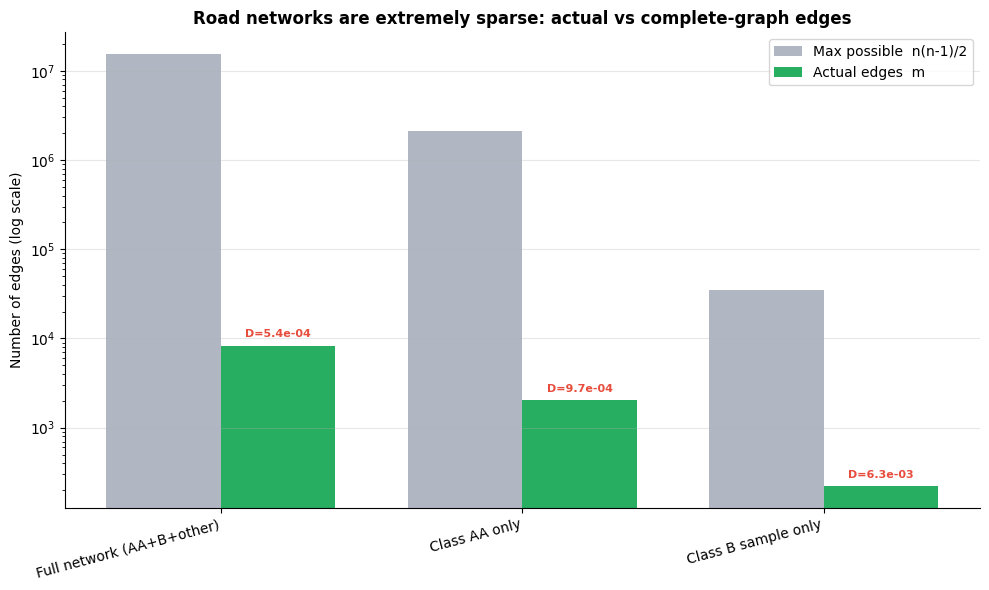

✅ Density chart saved to outputs/chart_network_density.png


In [13]:
# ── 5c (figure). Actual vs theoretical-maximum edges (log scale) ─────────────
fig, ax = plt.subplots(figsize=(10, 6))
labels = [r['network'] for r in rows]
x      = np.arange(len(labels))
w      = 0.38
actual = [r['edges_undirected_m']   for r in rows]
maxpos = [r['max_edges_n(n-1)/2']   for r in rows]

ax.bar(x - w/2, maxpos, w, label='Max possible  n(n-1)/2', color='#b0b7c3')
ax.bar(x + w/2, actual, w, label='Actual edges  m',        color='#27ae60')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Number of edges (log scale)')
ax.set_title('Road networks are extremely sparse: actual vs complete-graph edges',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.spines[['top', 'right']].set_visible(False)
for xi, (a, mx) in enumerate(zip(actual, maxpos)):
    d = a / mx if mx else 0
    ax.annotate(f'D={d:.1e}', xy=(xi + w/2, a), xytext=(0, 6),
                textcoords='offset points', ha='center', fontsize=8,
                color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_network_density.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Density chart saved to {OUTPUT_DIR}/chart_network_density.png")


---
## 6. Visualisation

The visualisation section is organised like the original notebook:
- network map
- validation chart
- junction degree distribution


### 6a. Class AA Road Network Map

This map follows the same purpose as the original Class AA visualisation, while using the AA-only subset from the combined pipeline.


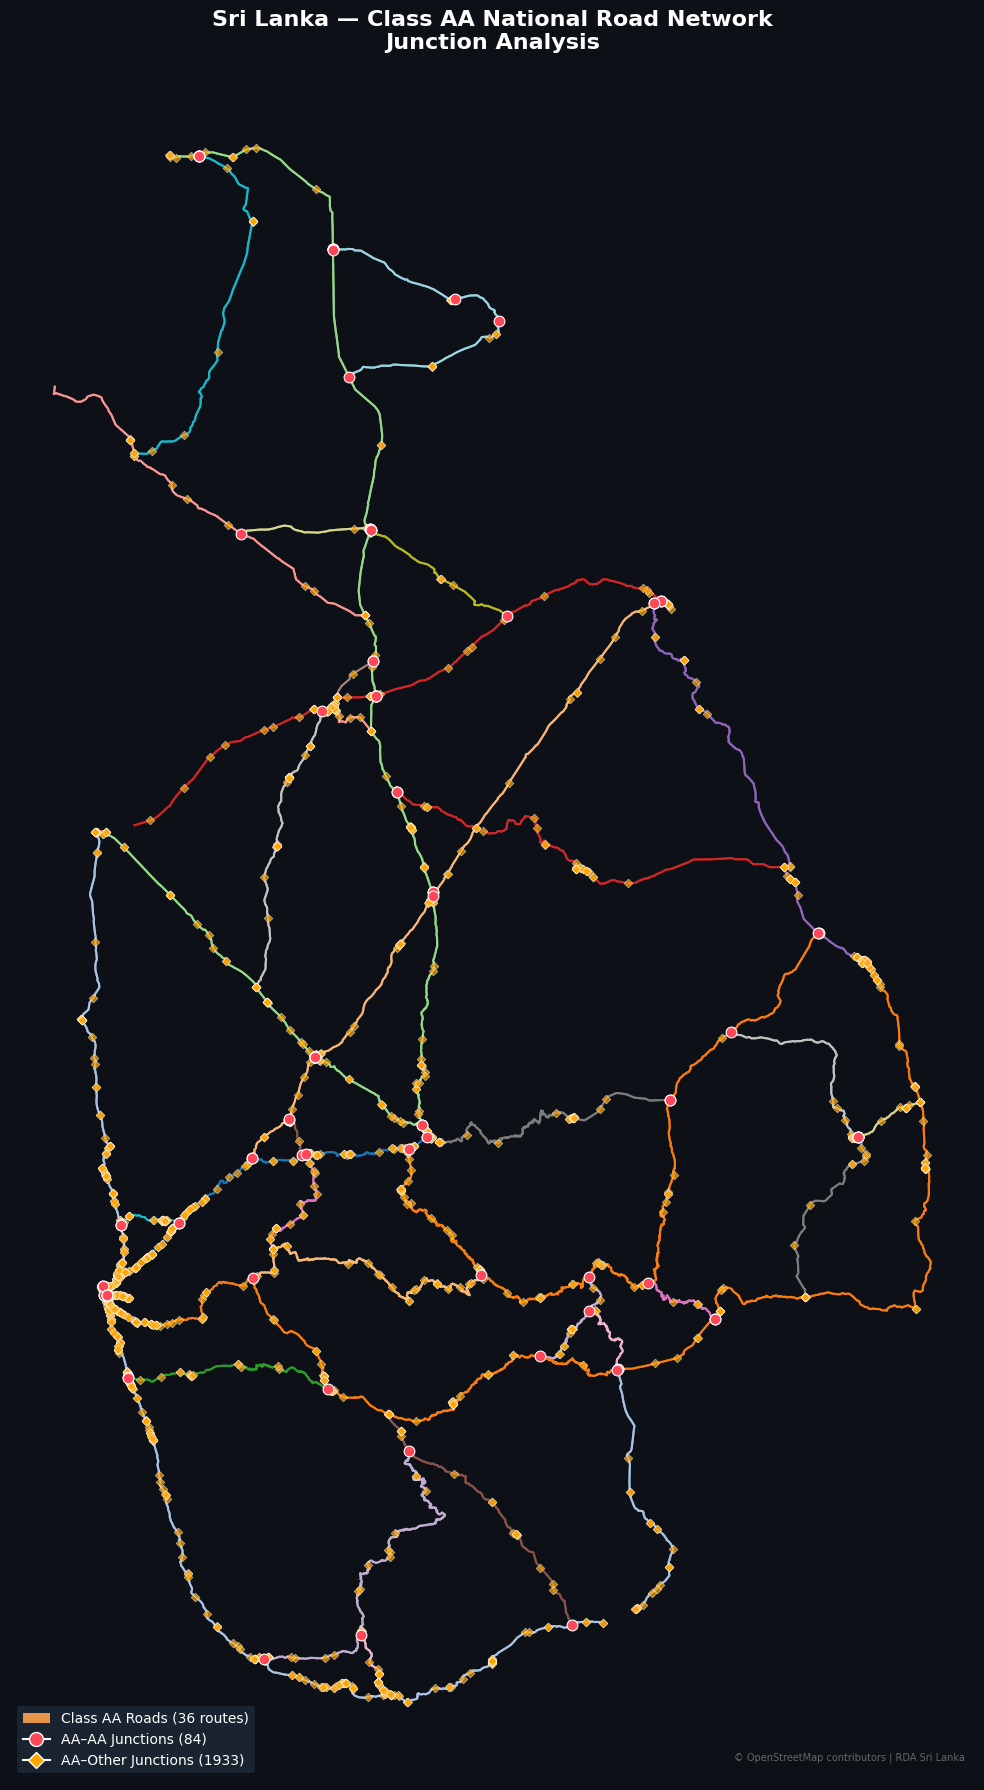

Map saved to outputs/map_aa_network.png


In [14]:
# ── Colour palette per AA road (36 roads → 36 colours) ─────────────────────
cmap_aa = plt.get_cmap('tab20', max(len(df_rda), 1))
cmap_b  = plt.get_cmap('winter', max(len(df_rda_b), 1))
ref_to_color = {
    **{row.osm_ref: cmap_aa(idx) for idx, row in df_rda.iterrows()},
    **{row.osm_ref: cmap_b(idx)  for idx, row in df_rda_b.iterrows()},
}

fig, ax = plt.subplots(figsize=(14, 18), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

for ref, group in edges_aa_only.groupby('matched_ref'):
    group.plot(ax=ax, color=ref_to_color.get(ref, '#ffffff'), linewidth=1.5,
               alpha=0.85, zorder=1)

# AA–AA junctions (red circles)
gdf_aa_aa = gdf_junctions[gdf_junctions['is_aa_aa_junction']]
gdf_aa_aa.plot(ax=ax, color='#ff4757', markersize=60, alpha=1.0,
               edgecolor='white', linewidth=0.8, zorder=3)

# AA–Other junctions (yellow diamonds)
gdf_aa_other = gdf_junctions[~gdf_junctions['is_aa_aa_junction']]
gdf_aa_other.plot(ax=ax, color='#ffa502', markersize=20, alpha=0.7,
                  edgecolor='white', linewidth=0.4, zorder=2, marker='D')

legend_elements = [
    mpatches.Patch(facecolor='#e8944a', label=f'Class AA Roads ({len(df_rda)} routes)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff4757',
               markersize=10, label=f'AA–AA Junctions ({n_aa_aa})'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#ffa502',
               markersize=8,  label=f'AA–Other Junctions ({n_total - n_aa_aa})'),
]
ax.legend(handles=legend_elements, loc='lower left', facecolor='#1e2a38',
          edgecolor='none', labelcolor='white', fontsize=10)
ax.set_title('Sri Lanka — Class AA National Road Network\nJunction Analysis',
             color='white', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
ax.text(0.99, 0.01, '© OpenStreetMap contributors | RDA Sri Lanka',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7, color='#666666')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/map_aa_network.png", dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(f'Map saved to {OUTPUT_DIR}/map_aa_network.png')


### 6b. Class B Road Network Map

Static map for the sampled Class B roads, using the same visual style as the AA road map.


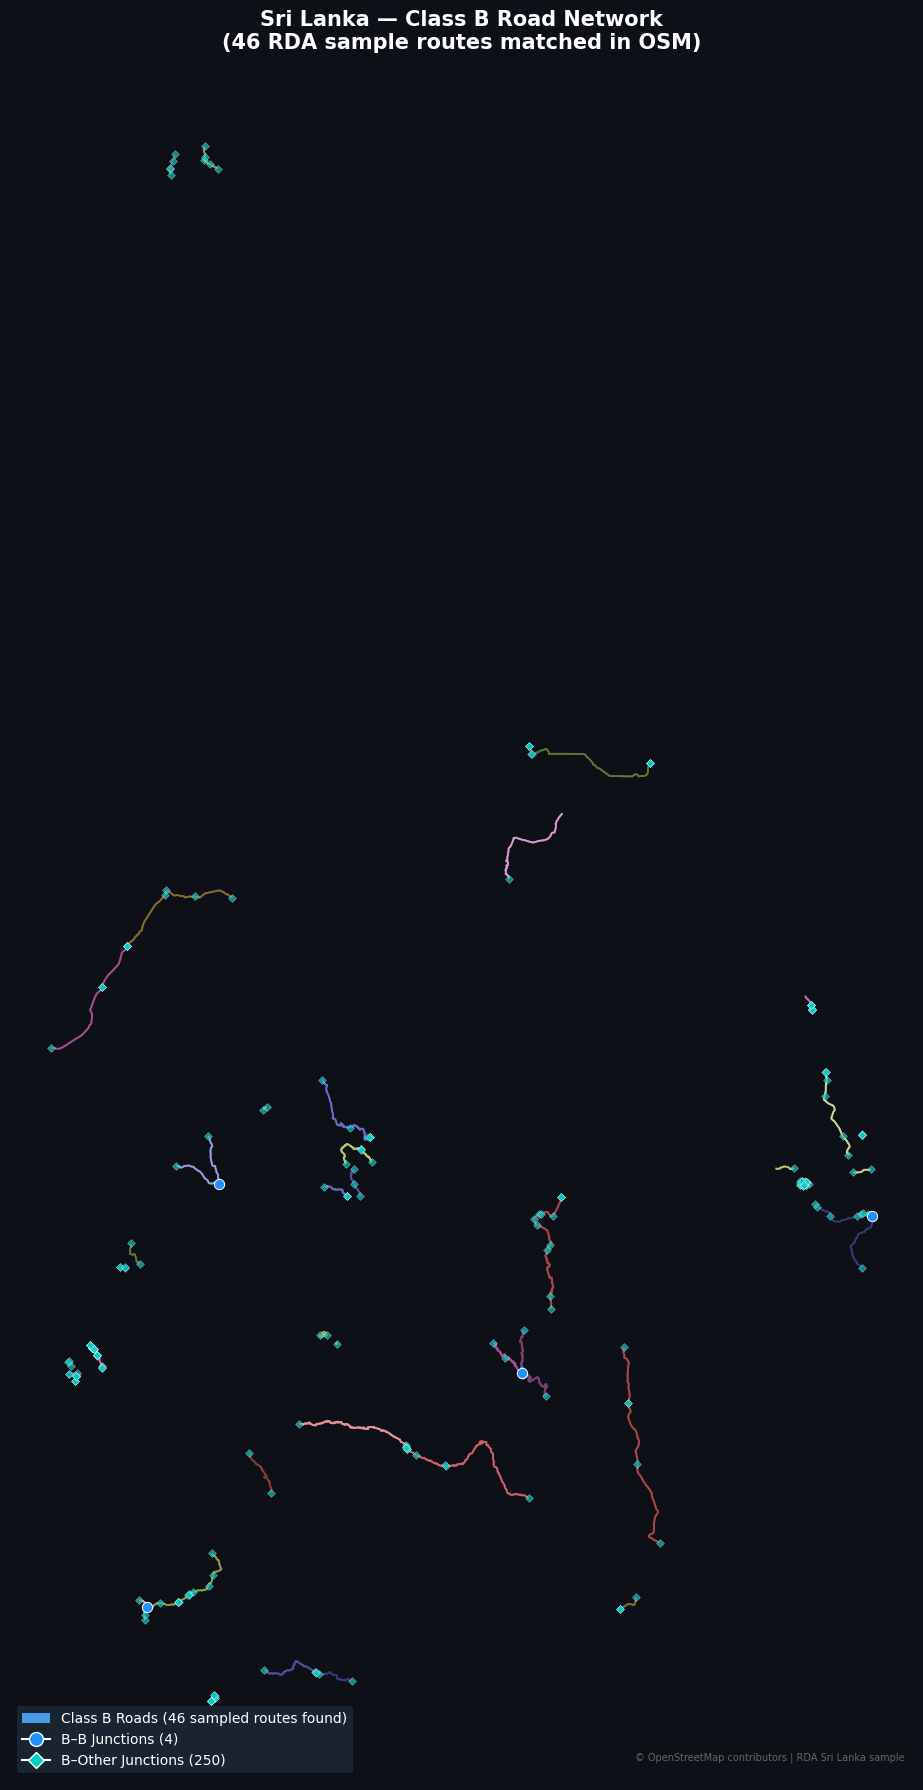

Map saved to outputs/map_classB_roads_network.png


In [15]:
# ── Colour palette for sampled B roads ─────────────────────────────────────
unique_b_refs = sorted(edges_b_only['matched_ref'].dropna().unique(), key=lambda x: int(x[1:]) if str(x)[1:].isdigit() else 10**9)
n_b_refs = len(unique_b_refs)
cmap_b_map = plt.get_cmap('tab20b', max(n_b_refs, 1))
b_ref_color = {ref: cmap_b_map(i % max(n_b_refs, 1)) for i, ref in enumerate(unique_b_refs)}

fig, ax = plt.subplots(figsize=(14, 18), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

for ref, group in edges_b_only.groupby('matched_ref'):
    group.plot(ax=ax, color=b_ref_color.get(ref, '#aaaaaa'), linewidth=1.3, alpha=0.85, zorder=1)

if len(gdf_junctions_b):
    gdf_bb = gdf_junctions_b[gdf_junctions_b['is_b_b_junction']]
    if len(gdf_bb):
        gdf_bb.plot(ax=ax, color='#1e90ff', markersize=55, alpha=1.0, edgecolor='white', linewidth=0.7, zorder=3)
    gdf_b_other = gdf_junctions_b[~gdf_junctions_b['is_b_b_junction']]
    if len(gdf_b_other):
        gdf_b_other.plot(ax=ax, color='#00cec9', markersize=16, alpha=0.65, edgecolor='white', linewidth=0.3, zorder=2, marker='D')

legend_elements_b = [
    mpatches.Patch(facecolor='#4a9be8', label=f'Class B Roads ({n_b_refs} sampled routes found)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1e90ff', markersize=10, label=f'B–B Junctions ({n_bb})'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#00cec9', markersize=8, label=f'B–Other Junctions ({n_b_total - n_bb})'),
]
ax.legend(handles=legend_elements_b, loc='lower left', facecolor='#1e2a38', edgecolor='none', labelcolor='white', fontsize=10)
ax.set_title(f'Sri Lanka — Class B Road Network\n({n_b_refs} RDA sample routes matched in OSM)', color='white', fontsize=15, fontweight='bold', pad=14)
ax.axis('off')
ax.text(0.99, 0.01, '© OpenStreetMap contributors | RDA Sri Lanka sample', transform=ax.transAxes, ha='right', va='bottom', fontsize=7, color='#666666')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/map_classB_roads_network.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Map saved to {OUTPUT_DIR}/map_classB_roads_network.png')


### 6c. Validation Charts — AA and B Separately

The original AA chart remains saved as `chart_length_validation.png` from the AA cell. This cell adds a separate B validation chart and an optional combined AA+B comparison chart.


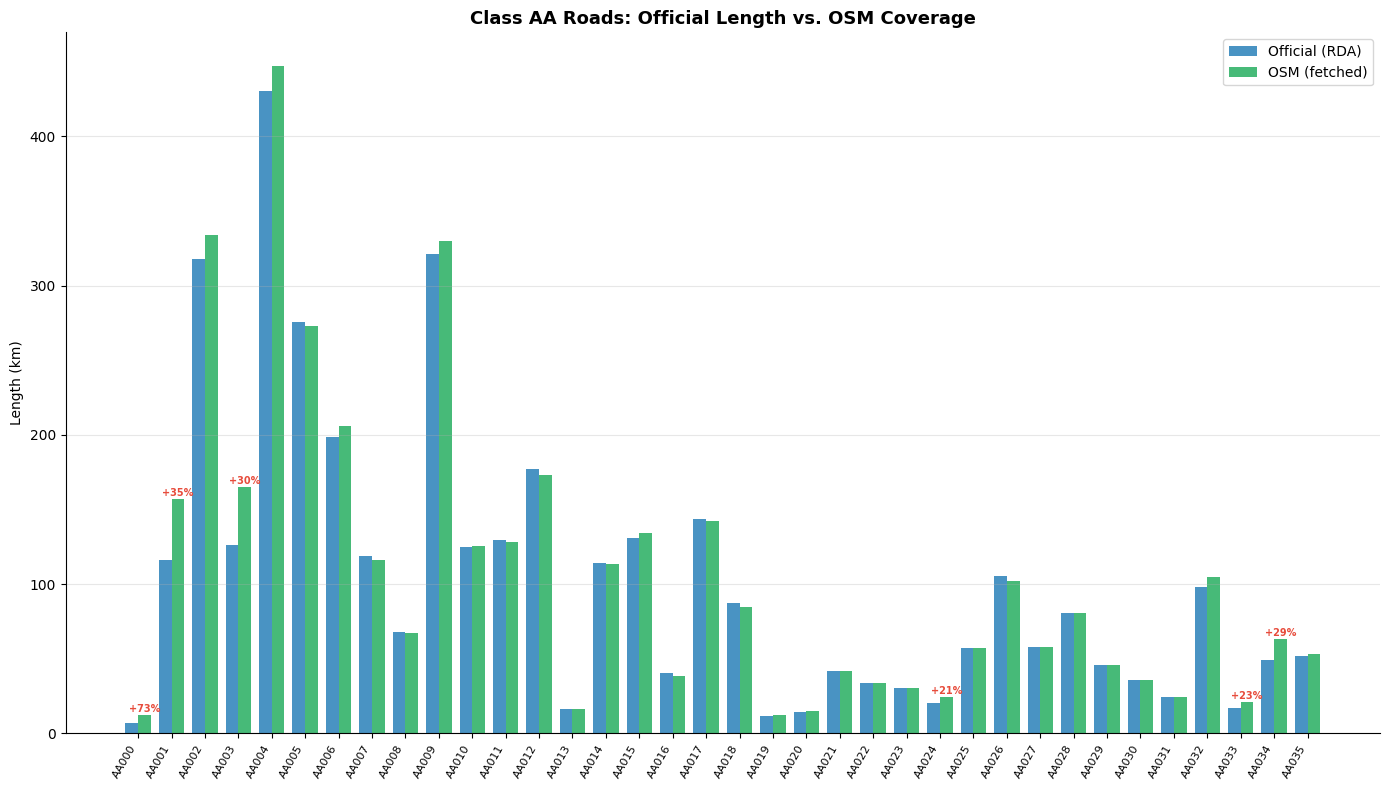

✅ AA validation chart saved to outputs/chart_length_validation.png


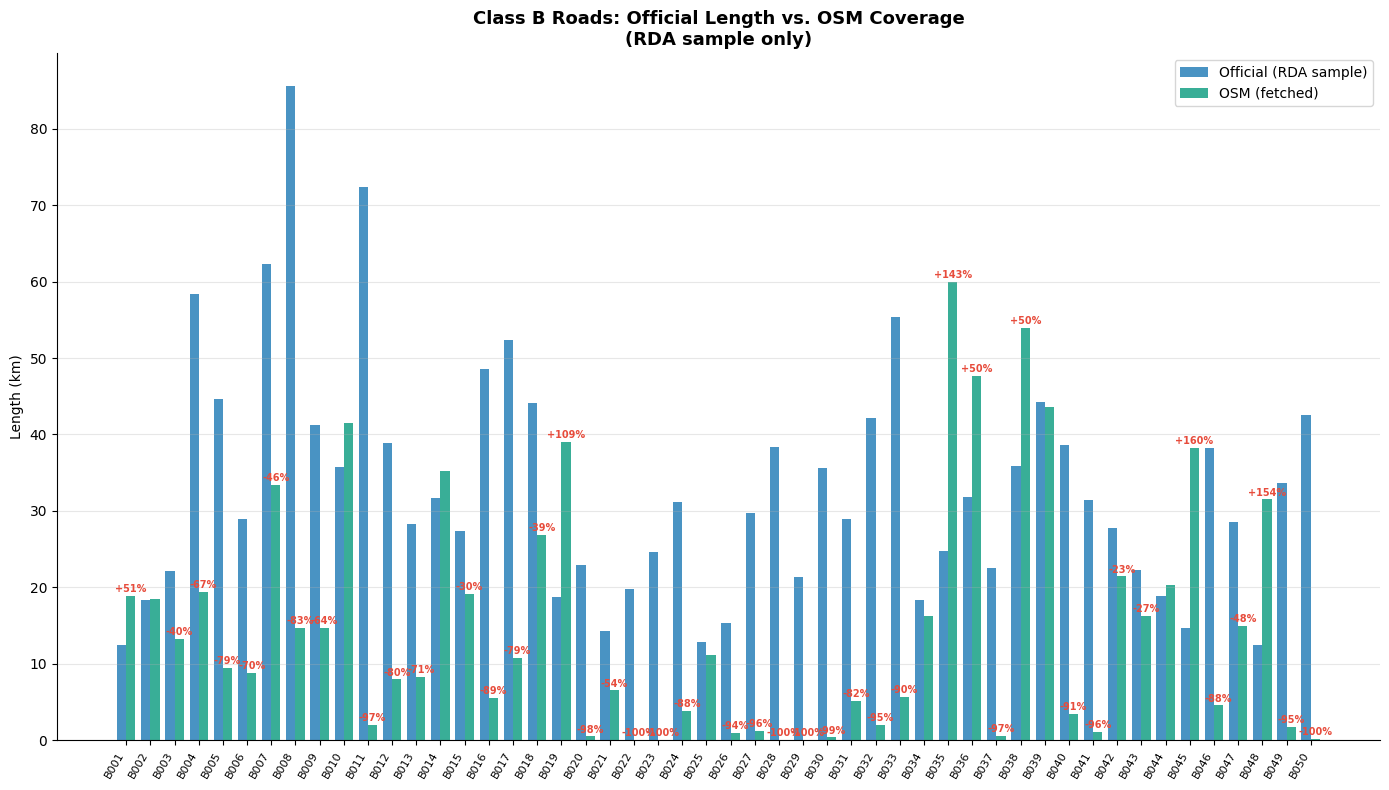

✅ B validation chart saved to outputs/chart_b_length_validation.png


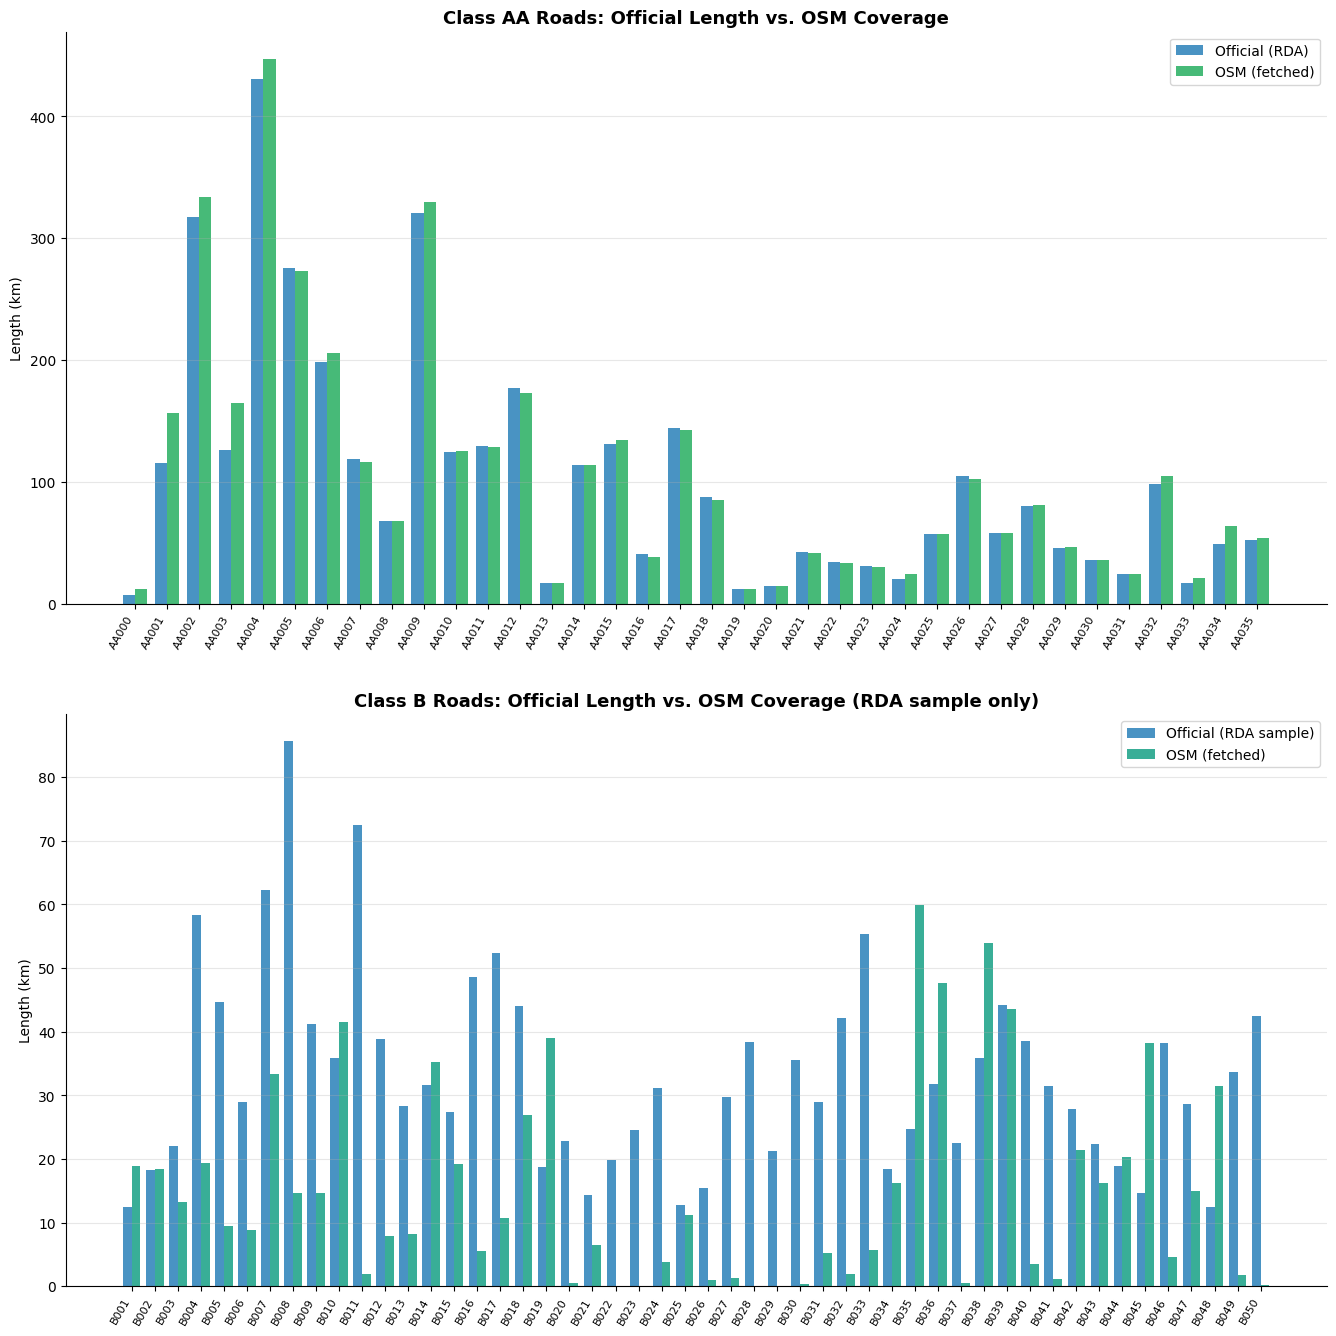

✅ Combined AA+B validation chart saved to outputs/chart_length_validation_aa_b.png


In [16]:
# ── Class AA validation chart (standalone, mirrors original notebook) ───────
width = 0.38
fig, ax = plt.subplots(figsize=(14, 8))
x_aa0 = np.arange(len(df_validation))
ax.bar(x_aa0 - width/2, df_validation['official_length_km'], width, label='Official (RDA)', color='#2980b9', alpha=0.85)
ax.bar(x_aa0 + width/2, df_validation['osm_length_km'], width, label='OSM (fetched)', color='#27ae60', alpha=0.85)
ax.set_xticks(x_aa0)
ax.set_xticklabels(df_validation['route_no'], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Length (km)')
ax.set_title('Class AA Roads: Official Length vs. OSM Coverage', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
for i, row in df_validation.iterrows():
    if abs(row['diff_pct']) > 20:
        ax.annotate(f"{row['diff_pct']:+.0f}%", xy=(i + width/2, row['osm_length_km'] + 2), ha='center', fontsize=7, color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_length_validation.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ AA validation chart saved to {OUTPUT_DIR}/chart_length_validation.png")

# ── Class B validation chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_validation_b))
width = 0.38

ax.bar(x - width/2, df_validation_b['official_length_km'], width, label='Official (RDA sample)', color='#2980b9', alpha=0.85)
ax.bar(x + width/2, df_validation_b['osm_length_km'], width, label='OSM (fetched)', color='#16a085', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_validation_b['route_no'], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Length (km)')
ax.set_title('Class B Roads: Official Length vs. OSM Coverage\n(RDA sample only)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
for i, row in df_validation_b.iterrows():
    if abs(row['diff_pct']) > 20:
        ax.annotate(f"{row['diff_pct']:+.0f}%", xy=(i + width/2, row['osm_length_km'] + 0.5), ha='center', fontsize=7, color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_b_length_validation.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ B validation chart saved to {OUTPUT_DIR}/chart_b_length_validation.png")

# ── Optional combined AA+B chart ─────────────────────────────────────────────
fig, (ax_aa, ax_b) = plt.subplots(2, 1, figsize=(14, 14))
x_aa = np.arange(len(df_validation))
ax_aa.bar(x_aa - width/2, df_validation['official_length_km'], width, label='Official (RDA)', color='#2980b9', alpha=0.85)
ax_aa.bar(x_aa + width/2, df_validation['osm_length_km'], width, label='OSM (fetched)', color='#27ae60', alpha=0.85)
ax_aa.set_xticks(x_aa)
ax_aa.set_xticklabels(df_validation['route_no'], rotation=60, ha='right', fontsize=8)
ax_aa.set_ylabel('Length (km)')
ax_aa.set_title('Class AA Roads: Official Length vs. OSM Coverage', fontsize=13, fontweight='bold')
ax_aa.legend(); ax_aa.grid(axis='y', alpha=0.3); ax_aa.spines[['top','right']].set_visible(False)

x_b = np.arange(len(df_validation_b))
ax_b.bar(x_b - width/2, df_validation_b['official_length_km'], width, label='Official (RDA sample)', color='#2980b9', alpha=0.85)
ax_b.bar(x_b + width/2, df_validation_b['osm_length_km'], width, label='OSM (fetched)', color='#16a085', alpha=0.85)
ax_b.set_xticks(x_b)
ax_b.set_xticklabels(df_validation_b['route_no'], rotation=60, ha='right', fontsize=8)
ax_b.set_ylabel('Length (km)')
ax_b.set_title('Class B Roads: Official Length vs. OSM Coverage (RDA sample only)', fontsize=13, fontweight='bold')
ax_b.legend(); ax_b.grid(axis='y', alpha=0.3); ax_b.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig(f"{OUTPUT_DIR}/chart_length_validation_aa_b.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Combined AA+B validation chart saved to {OUTPUT_DIR}/chart_length_validation_aa_b.png")


### 6d. Junction Degree Distribution — AA and B Separately


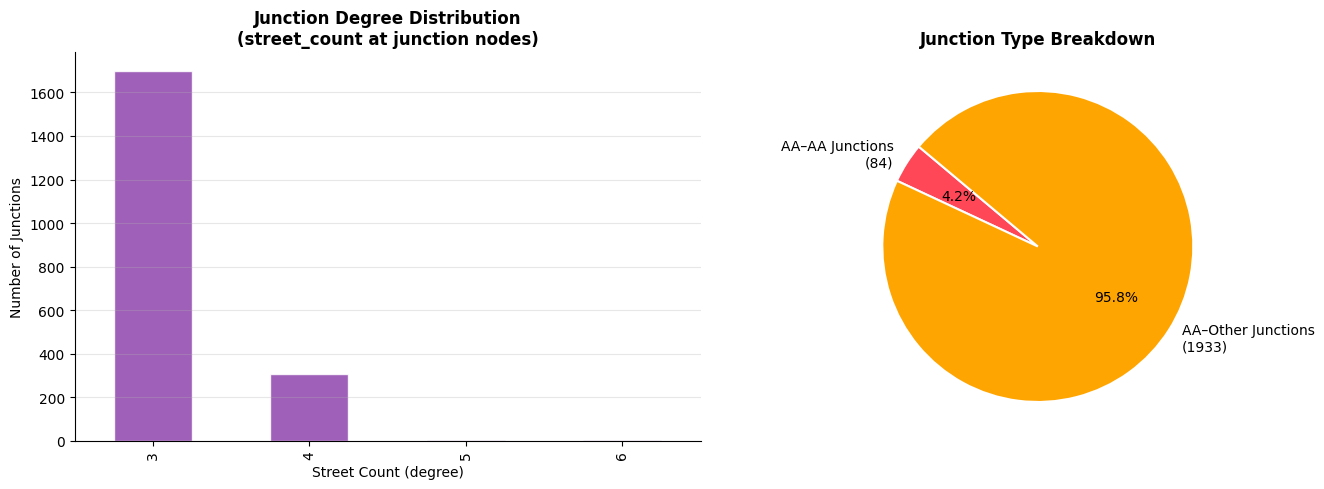

✅ AA junction stats saved to outputs/chart_junction_stats.png


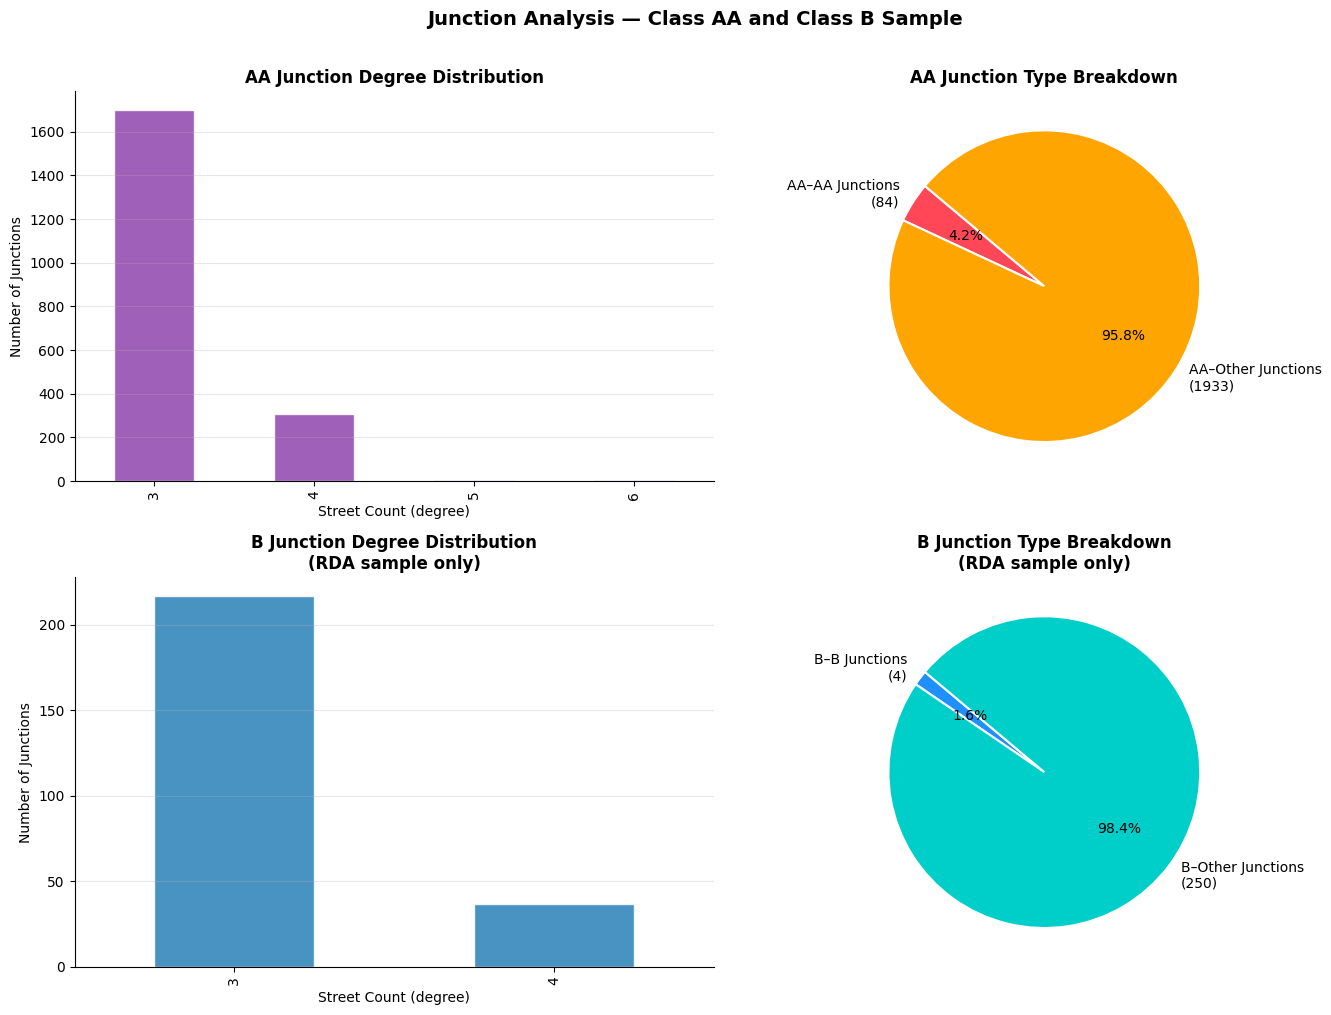

✅ Junction charts saved.


In [17]:
# ── Class AA junction stats (standalone, mirrors original notebook) ────────
fig0, axes0 = plt.subplots(1, 2, figsize=(14, 5))
df_junctions['street_count'].value_counts().sort_index().plot(kind='bar', ax=axes0[0], color='#8e44ad', edgecolor='white', alpha=0.85)
axes0[0].set_title('Junction Degree Distribution\n(street_count at junction nodes)', fontweight='bold')
axes0[0].set_xlabel('Street Count (degree)'); axes0[0].set_ylabel('Number of Junctions')
axes0[0].grid(axis='y', alpha=0.3); axes0[0].spines[['top','right']].set_visible(False)
sizes0 = [n_aa_aa, n_total - n_aa_aa]
labels0 = [f'AA–AA Junctions\n({n_aa_aa})', f'AA–Other Junctions\n({n_total - n_aa_aa})']
axes0[1].pie(sizes0, labels=labels0, colors=['#ff4757', '#ffa502'], autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes0[1].set_title('Junction Type Breakdown', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_junction_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ AA junction stats saved to {OUTPUT_DIR}/chart_junction_stats.png")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_junctions['street_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0,0].set_title('AA Junction Degree Distribution', fontweight='bold')
axes[0,0].set_xlabel('Street Count (degree)'); axes[0,0].set_ylabel('Number of Junctions')
axes[0,0].grid(axis='y', alpha=0.3); axes[0,0].spines[['top','right']].set_visible(False)

sizes_aa = [n_aa_aa, n_total - n_aa_aa]
labels_aa = [f'AA–AA Junctions\n({n_aa_aa})', f'AA–Other Junctions\n({n_total - n_aa_aa})']
axes[0,1].pie(sizes_aa, labels=labels_aa, colors=['#ff4757','#ffa502'], autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0,1].set_title('AA Junction Type Breakdown', fontweight='bold')

if len(df_junctions_b):
    df_junctions_b['street_count'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='#2980b9', edgecolor='white', alpha=0.85)
else:
    axes[1,0].text(0.5, 0.5, 'No B junctions found', ha='center', va='center')
axes[1,0].set_title('B Junction Degree Distribution\n(RDA sample only)', fontweight='bold')
axes[1,0].set_xlabel('Street Count (degree)'); axes[1,0].set_ylabel('Number of Junctions')
axes[1,0].grid(axis='y', alpha=0.3); axes[1,0].spines[['top','right']].set_visible(False)

sizes_b = [n_bb, n_b_total - n_bb]
labels_b = [f'B–B Junctions\n({n_bb})', f'B–Other Junctions\n({n_b_total - n_bb})']
if sum(sizes_b) > 0:
    axes[1,1].pie(sizes_b, labels=labels_b, colors=['#1e90ff','#00cec9'], autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
else:
    axes[1,1].text(0.5, 0.5, 'No B junctions found', ha='center', va='center')
axes[1,1].set_title('B Junction Type Breakdown\n(RDA sample only)', fontweight='bold')

plt.suptitle('Junction Analysis — Class AA and Class B Sample', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_junction_stats_aa_b.png", dpi=150, bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIR}/chart_b_junction_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print('✅ Junction charts saved.')


---
## 7. Export Datasets

This mirrors the original notebook's export step, but writes separate AA+B and B-specific outputs.


In [18]:
# ── 7a. Junctions CSV ─────────────────────────────────────────────────────────
junctions_export = df_junctions[[
    'node_id', 'latitude', 'longitude',
    'street_count', 'n_aa_roads', 'aa_roads',
    'junction_type', 'is_aa_aa_junction', 'is_aa_any_junction', 'is_b_road'
]].copy()
junctions_export = junctions_export.round({'latitude': 6, 'longitude': 6})
junctions_path = f"{OUTPUT_DIR}/sri_lanka_rda_aa_b_junctions.csv"
junctions_export.to_csv(junctions_path, index=False)
print(f"✅ Junctions CSV  -> {junctions_path}  ({len(junctions_export):,} rows)")

# ── 7b. Roads summary CSV ─────────────────────────────────────────────────────
roads_summary = df_validation[[
    'route_no', 'osm_ref', 'road_name',
    'official_length_km', 'osm_length_km', 'diff_km', 'diff_pct', 'coverage_flag'
]].copy()

def count_junctions_for_ref(ref, aa_only=False):
    mask = df_junctions['aa_roads'].apply(lambda r: ref in r.split(';'))
    if aa_only:
        mask = mask & df_junctions['is_aa_aa_junction']
    return int(mask.sum())

roads_summary['n_junctions_total'] = roads_summary['osm_ref'].apply(
    lambda ref: count_junctions_for_ref(ref, aa_only=False)
)
roads_summary['n_aa_aa_junctions'] = roads_summary['osm_ref'].apply(
    lambda ref: count_junctions_for_ref(ref, aa_only=True)
)
roads_path = f"{OUTPUT_DIR}/sri_lanka_rda_aa_b_roads_summary.csv"
roads_summary.to_csv(roads_path, index=False)
print(f"✅ Roads summary  -> {roads_path}  ({len(roads_summary):,} rows)")

# ── 7c. Edges (raw segments) CSV ──────────────────────────────────────────────
# edges_aa_proj was created from edges_aa which lost u/v into columns after merge.
# Re-use edges_aa_reset (which has u/v as proper columns) joined with lengths.
edges_aa_reset_proj = edges_aa_reset.copy()
edges_aa_reset_proj = edges_aa_reset_proj.set_geometry('geometry').to_crs(epsg=5235)
edges_aa_reset_proj['segment_length_m'] = edges_aa_reset_proj.geometry.length

# Merge road names back in
edges_aa_reset_proj = edges_aa_reset_proj.merge(
    df_rda_all[['osm_ref', 'route_no', 'road_name']],
    left_on='matched_ref', right_on='osm_ref',
    how='left'
)

# Select available columns safely
wanted = ['u', 'v', 'matched_ref', 'route_no', 'road_name',
          'highway', 'oneway', 'maxspeed', 'lanes', 'name', 'segment_length_m']
available = [c for c in wanted if c in edges_aa_reset_proj.columns]
edges_export = edges_aa_reset_proj[available].copy()

edges_path = f"{OUTPUT_DIR}/sri_lanka_rda_aa_b_road_segments.csv"
edges_export.to_csv(edges_path, index=False)
print(f"✅ Road segments  -> {edges_path}  ({len(edges_export):,} rows)")


✅ Junctions CSV  -> outputs/sri_lanka_rda_aa_b_junctions.csv  (2,017 rows)
✅ Roads summary  -> outputs/sri_lanka_rda_aa_b_roads_summary.csv  (36 rows)
✅ Road segments  -> outputs/sri_lanka_rda_aa_b_road_segments.csv  (2,860 rows)


### 7b. Class B Export Files

Exports for the sampled Class B roads only, matching the structure of the original AA exports.


In [19]:
# ── 7b-i. B Junctions CSV ────────────────────────────────────────────────────
b_junctions_export = df_junctions_b[[
    'node_id', 'latitude', 'longitude',
    'street_count', 'n_b_roads', 'b_roads',
    'junction_type', 'is_b_b_junction', 'is_b_any_junction'
]].copy()
b_junctions_export = b_junctions_export.round({'latitude': 6, 'longitude': 6})
b_junctions_path = f"{OUTPUT_DIR}/sri_lanka_b_junctions.csv"
b_junctions_export.to_csv(b_junctions_path, index=False)
print(f"✅ B Junctions CSV  -> {b_junctions_path}  ({len(b_junctions_export):,} rows)")

def count_b_junctions_for_ref(ref, bb_only=False):
    if len(df_junctions_b) == 0:
        return 0
    mask = df_junctions_b['b_roads'].apply(lambda r: ref in str(r).split(';'))
    if bb_only:
        mask = mask & df_junctions_b['is_b_b_junction']
    return int(mask.sum())

b_roads_summary = df_validation_b[[
    'route_no', 'osm_ref', 'road_name',
    'official_length_km', 'osm_length_km', 'diff_km', 'diff_pct', 'coverage_flag'
]].copy()
b_roads_summary['n_junctions_total'] = b_roads_summary['osm_ref'].apply(lambda ref: count_b_junctions_for_ref(ref, bb_only=False))
b_roads_summary['n_b_b_junctions'] = b_roads_summary['osm_ref'].apply(lambda ref: count_b_junctions_for_ref(ref, bb_only=True))
b_roads_path = f"{OUTPUT_DIR}/sri_lanka_b_roads_summary.csv"
b_roads_summary.to_csv(b_roads_path, index=False)
print(f"✅ B Roads summary  -> {b_roads_path}  ({len(b_roads_summary):,} rows)")

edges_b_reset_proj = gpd.GeoDataFrame(edges_b_reset.copy(), geometry='geometry', crs=edges.crs).to_crs(epsg=5235)
edges_b_reset_proj['segment_length_m'] = edges_b_reset_proj.geometry.length
edges_b_reset_proj = edges_b_reset_proj.merge(df_rda_b[['osm_ref', 'route_no', 'road_name']], left_on='matched_ref', right_on='osm_ref', how='left')

wanted_b = ['u', 'v', 'matched_ref', 'route_no', 'road_name', 'highway', 'oneway', 'maxspeed', 'lanes', 'name', 'segment_length_m']
available_b = [c for c in wanted_b if c in edges_b_reset_proj.columns]
b_edges_export = edges_b_reset_proj[available_b].copy()
b_edges_path = f"{OUTPUT_DIR}/sri_lanka_b_road_segments.csv"
b_edges_export.to_csv(b_edges_path, index=False)
print(f"✅ B Road segments  -> {b_edges_path}  ({len(b_edges_export):,} rows)")


✅ B Junctions CSV  -> outputs/sri_lanka_b_junctions.csv  (254 rows)
✅ B Roads summary  -> outputs/sri_lanka_b_roads_summary.csv  (50 rows)
✅ B Road segments  -> outputs/sri_lanka_b_road_segments.csv  (368 rows)


---
## 8. Final Summary

The final summary follows the same structure as the original notebook, with separate AA and B totals.


In [20]:
print("=" * 65)
print("  SRI LANKA ROAD NETWORK — COMPLETE ANALYSIS SUMMARY")
print("=" * 65)
print()
print(f"  Data source    : OpenStreetMap (via osmnx)")
print(f"  Ground truth   : RDA Sri Lanka AA network + Class B road sample")
print()
print("  ── CLASS AA ROADS ─────────────────────────────────────────")
print(f"  Roads in RDA dataset        : {len(df_rda)}")
print(f"  Roads found in OSM          : {edges_aa['matched_ref'].nunique()}")
print(f"  Roads missing from OSM      : {len(df_rda) - edges_aa['matched_ref'].nunique()}")
print(f"  Official total length       : {df_rda['official_length_km'].sum():.2f} km")
print(f"  OSM total length            : {df_validation['osm_length_km'].sum():.2f} km")
print(f"  AA–AA junctions             : {n_aa_aa}")
print(f"  AA–Any junctions            : {n_aa_any}")
print(f"  Total AA junctions          : {n_total}")
print()
print("  ── CLASS B ROADS ──────────────────────────────────────────")
print(f"  Roads in RDA sample         : {len(df_rda_b)}")
print(f"  Sample roads found in OSM   : {edges_b_only['matched_ref'].nunique()} / {len(df_rda_b)}")
print(f"  Official total, B sample    : {df_rda_b['official_length_km'].sum():.2f} km")
print(f"  OSM total, B sample         : {df_validation_b['osm_length_km'].sum():.2f} km")
good_b  = (df_validation_b['coverage_flag'] == '✅ Good').sum()
under_b = (df_validation_b['coverage_flag'] == '❌ Under').sum()
over_b  = (df_validation_b['coverage_flag'] == '⚠️ Over').sum()
print(f"  Sample coverage flags       : {good_b} good | {under_b} under | {over_b} over")
print(f"  B–B junctions               : {n_bb}")
print(f"  B–Any junctions             : {n_b_any}")
print(f"  Total B junctions           : {n_b_total}")
print()
print("  ── EXPORTED FILES ─────────────────────────────────────────")
print(f"  Class AA:")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_rda_aa_b_junctions.csv")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_rda_aa_b_roads_summary.csv")
print(f"    └─ {OUTPUT_DIR}/sri_lanka_rda_aa_b_road_segments.csv")
print(f"  Class B:")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_b_junctions.csv")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_b_roads_summary.csv")
print(f"    └─ {OUTPUT_DIR}/sri_lanka_b_road_segments.csv")
print(f"  Maps/charts:")
print(f"    ├─ {OUTPUT_DIR}/map_aa_network.png")
print(f"    ├─ {OUTPUT_DIR}/map_classB_roads_network.png")
print(f"    ├─ {OUTPUT_DIR}/chart_length_validation.png")
print(f"    ├─ {OUTPUT_DIR}/chart_b_length_validation.png")
print(f"    ├─ {OUTPUT_DIR}/chart_length_validation_aa_b.png")
print(f"    ├─ {OUTPUT_DIR}/chart_junction_stats.png")
print(f"    ├─ {OUTPUT_DIR}/chart_junction_stats_aa_b.png")
print(f"    └─ {OUTPUT_DIR}/chart_b_junction_stats.png")
print()
print("  ⚠️  Notes:")
print("    - This notebook is based on the structure of sri_lanka_roads (1).ipynb.")
print("    - Class B analysis is limited to the RDA B-road sample defined in Section 1b.")
print("    - B refs are normalised: B008, B08, and B8 are treated as the same road.")
print("    - OSM data is community-maintained; coverage varies by region.")
print("    - Coordinate system for outputs: WGS84 (EPSG:4326); metric calculations use EPSG:5235.")
print("=" * 65)


  SRI LANKA ROAD NETWORK — COMPLETE ANALYSIS SUMMARY

  Data source    : OpenStreetMap (via osmnx)
  Ground truth   : RDA Sri Lanka AA network + Class B road sample

  ── CLASS AA ROADS ─────────────────────────────────────────
  Roads in RDA dataset        : 36
  Roads found in OSM          : 36
  Roads missing from OSM      : 0
  Official total length       : 3720.31 km
  OSM total length            : 3867.53 km
  AA–AA junctions             : 84
  AA–Any junctions            : 2017
  Total AA junctions          : 2017

  ── CLASS B ROADS ──────────────────────────────────────────
  Roads in RDA sample         : 50
  Sample roads found in OSM   : 46 / 50
  Official total, B sample    : 1651.10 km
  OSM total, B sample         : 760.40 km
  Sample coverage flags       : 3 good | 38 under | 9 over
  B–B junctions               : 4
  B–Any junctions             : 254
  Total B junctions           : 254

  ── EXPORTED FILES ─────────────────────────────────────────
  Class AA:
    ├─ out